# Randomization testing

This practical assignment need to be handed in on Brightspace before the deadline, 16:00 15/05/2023. Make sure that every cell is executed/compiled and renamed to

**Assignment4_Surname1_Surname2.ipynb**

before submitting. For questions contact your TA during the workgroup, or via mail. Depending on whether all questions are sufficiently answered and if enough effort has been put into the assignment, you wil get good (all questions answered and all topics underestood well), sufficient (enough effort has been put but need to learn more and underestand better) or fail (not enough effort has been put into this assignment).

**Name 1:** Angelina Podolako - s1125886

**Name 2:** Feliks Lysiuk - s1125187

### Dataset

A game enthausiast claims that Xbox 360 games are better than PS2 games. To try to support his claim with some evidence, he randomly samples games from both consoles and collects information about the review scores that the sampled games received on the https://www.ign.com/reviews/games website. In the  dataset he collected, there is information about the game title, platform, the review score the games received, the genre and the release dates.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

In [20]:
# needed/convenient only  if you're working in Google colab (not for local Jupyter)
from google.colab import files
uploaded = files.upload()

Saving PS2_vs_Xbox360.csv to PS2_vs_Xbox360 (1).csv


In [21]:
games = pd.read_csv('PS2_vs_Xbox360.csv')
games.head()


,Unnamed: 0.1,Unnamed: 0,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
0,4101,4101,Amazing,Burnout 2: Point of Impact,/games/burnout-2-point-of-impact/ps2-481982,PlayStation 2,9.0,Racing,Y,2002,9,24
1,3361,3361,Bad,Yanya Caballista: City Skater,/games/yanya-caballista-city-skater/ps2-16279,PlayStation 2,4.0,Sports,N,2001,10,15
2,6989,6989,Okay,Suzuki TT Superbikes: Real Road Racing,/games/suzuki-tt-superbikes-real-road-racing/p...,PlayStation 2,6.1,Racing,N,2005,8,11
3,7404,7404,Great,Call of Duty 2: Big Red One (Collector's Edition),/games/call-of-duty-2-big-red-one/ps2-763356,PlayStation 2,8.0,Shooter,N,2005,11,9
4,4505,4505,Good,Star Wars: The Clone Wars,/games/star-wars-the-clone-wars/ps2-481948,PlayStation 2,7.6,Action,N,2002,12,13


### <span style="color:red"> Question 1 </span>
Our game enthousiast wants to test whether Xbox 360 games receive a higher review score than PS2 games. Write down the null- and alternative hypothesis.

**Answer**

Null Hypothesis  - Games on Xbox 360 receive the same review score as on PS2\
H0 =  μ xbox = μ ps\
Alternative Hypothesis - Games on Xbox 360 receive higher review score than  on PS2\
Ha =  μ xbox >  μ ps

### <span style="color:red"> Question 2 </span>
To make it easier for yourself to run the statistical tests and make plots, you can create two new variables that contain the data for the PS2 and Xbox 360 datasets. Look at your code from the previous weeks to find out how you can do that.

In [22]:
xbox_games = games[games['platform'] == "Xbox 360"]
xbox_games.head()
ps_games = games[games['platform'] == "PlayStation 2"]
ps_games.head()

,Unnamed: 0.1,Unnamed: 0,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
0,4101,4101,Amazing,Burnout 2: Point of Impact,/games/burnout-2-point-of-impact/ps2-481982,PlayStation 2,9.0,Racing,Y,2002,9,24
1,3361,3361,Bad,Yanya Caballista: City Skater,/games/yanya-caballista-city-skater/ps2-16279,PlayStation 2,4.0,Sports,N,2001,10,15
2,6989,6989,Okay,Suzuki TT Superbikes: Real Road Racing,/games/suzuki-tt-superbikes-real-road-racing/p...,PlayStation 2,6.1,Racing,N,2005,8,11
3,7404,7404,Great,Call of Duty 2: Big Red One (Collector's Edition),/games/call-of-duty-2-big-red-one/ps2-763356,PlayStation 2,8.0,Shooter,N,2005,11,9
4,4505,4505,Good,Star Wars: The Clone Wars,/games/star-wars-the-clone-wars/ps2-481948,PlayStation 2,7.6,Action,N,2002,12,13


### <span style="color:red"> Question 3 </span>
Before doing a statistical test, it is always a good idea to have a look at your data. Choose an appropriate plot to visualize the data. Show the data for both consoles seperately.
Do these data meet the normality assumptions required for a t-test? Does the plotted data suggest that the hypothesis of our game enthousiast may be right?

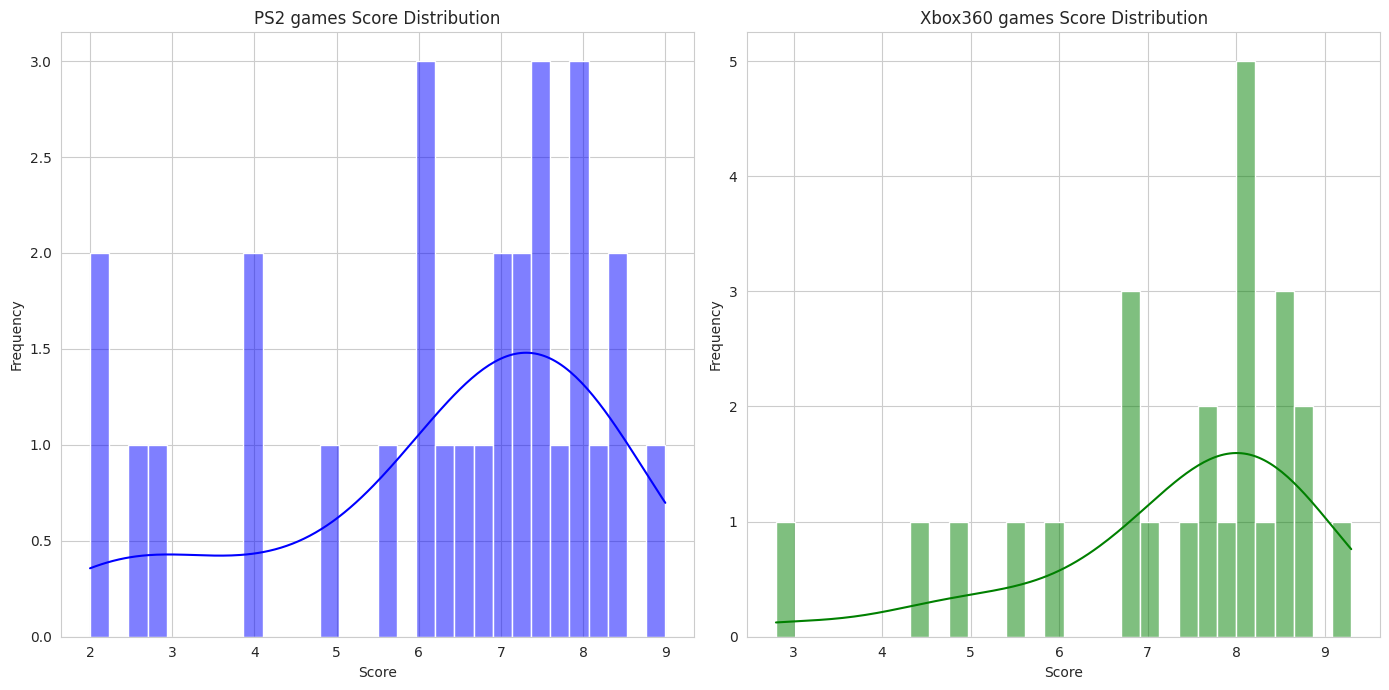

In [23]:
plt.figure(figsize=(14, 7))

plt.subplot(1,2,1)
sns.histplot(ps_games["score"], bins=30, kde=True, color="blue")
plt.title("PS2 games Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
sns.histplot(xbox_games["score"], bins=30, kde=True, color="green")
plt.title("Xbox360 games Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The data points are not perfect, but they are still distributed approximately symmetrically relative to the average value and have the shape of a bell, which means that this is a normal distribution. This is especially clearly seen with the help of "kde". That is, the data is suitable for the t test.

The average score of games on the xbox is higher and more shifted to the right than that of the PS2, this may confirm the theory of a game ethusiast.

Non-parameteric testing is a great alternative for datasets such as these. In this workgroup you will learn how you can use randomization to do hypothesis testing.

### <span style="color:red"> Question 4 </span>

Before we can do the randomization test, we will need to prepare some variables. Because the data are left skewed we will use the median instead of the mean to compare the two consoles. Do the following things:

 1. Calculate the difference in median score of both consoles, and store it in an appropriately named variable.
 2. Define how many randomization iterations you want to compute (usually 1000 or 10000), and create an empty numpy array of this size.

In [24]:
ps_score_median = np.median(ps_games["score"])
xbox_score_median = np.median(xbox_games["score"])

median_score_difference =  xbox_score_median - ps_score_median
print(median_score_difference)

num_iterations = 10000

random_diff_results = np.empty(num_iterations)

0.8999999999999995


### <span style="color:red"> Question 5 </span>

Create a for-loop that loops $n$ times (the number you defined in the last question). Inside the loop, randomly assign each score to a console. Each console should have as many scores as it originally had.

You can do this by:
1. shuffling all the rows of the 'games' pandas dataframe (using the sample method in pandas)
2. selecting the first x number of cases that will represent the Xbox 360 games.
3. selecting the remaining cases that represent the PS2 games.

After you randomly reassigned the rows to the consoles, you calculate the (randomized) differences in the medians of the scores of the two consoles. Store these median differences in a numpy array (that you created in the previous question).

In [25]:
for i in range (num_iterations):
    shuffled_games = games.sample(frac=1)

    xbox_scores = shuffled_games.head(len(xbox_games))["score"].values
    ps_scores = shuffled_games.tail(len(ps_games))["score"].values

    randomized_median_score_difference = (np.median(xbox_scores)) - (np.median(ps_scores))

    random_diff_results[i] = randomized_median_score_difference

### <span style="color:red"> Question 6 </span>

Now that all that randomization is done we want to obtain a p-value on the basis of which we can conclude whether Xbox360 games are rated higher than the PS2 games.

- Calculate the p-value (i.e. the probability that the randomized median differences are higher than the actual difference in the medians).

- Plot the randomized median differences and the actual median difference in one plot (use a `histplot` or `displot` to plot the randomized differences and use `plt.vlines` to plot the actual median difference)

0.0365


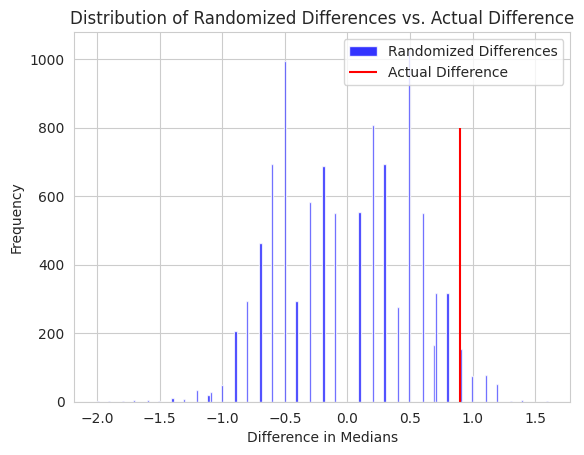

In [26]:
p_value = np.mean(random_diff_results >= median_score_difference)
print(p_value)

plt.hist(random_diff_results, bins=200, alpha=0.8, color='blue', label='Randomized Differences')
plt.vlines(x=median_score_difference, ymin=0, ymax=800, color='red', linestyle='-', label='Actual Difference')

plt.xlabel('Difference in Medians')
plt.ylabel('Frequency')
plt.title('Distribution of Randomized Differences vs. Actual Difference')
plt.legend()

plt.show()

### <span style="color:red"> Question 7 </span>
What would the p-value be for a 2-sided test?

In [30]:
random_diff_results, p_two_sided_value = stats.ttest_ind(xbox_scores, ps_scores)
print(p_two_sided_value)

0.4112361120056006


### <span style="color:red"> Question 8 </span>
Instead of randomization we could also use the Mann-Whitney U test in this case, which is a non-parametric test to compare whether data in one population are "higher" than in another. Use the scipy module `stats.mannwhitneyu` to run the test. How does the p-value compare to the one you got before?

In [28]:
test = stats.mannwhitneyu(xbox_scores, ps_scores)
print(test)

MannwhitneyuResult(statistic=381.0, pvalue=0.7544777530019593)


**Answer**

P-value we got from this module is slightly higher than that we got before.


### <span style="color:red"> Question 9 </span>
What is the conclusion of your hypothesis test?

**Answer**

Felix:
To conclude, we can see that exactly XBOX games are usually rated higher than PS games. It proves our alternative hypothesis (H_a)

Angelina:
Both methods do not give statistically significant results at the significance level α=0.05.This means that we cannot reject the null hypothesis.

Conclusion: Based on the hypothesis test, we cannot conclude that the ratings of games for Xbox360 are higher than for PS2.

In this assignment, we used a small sample of a larger dataset that you can find here in case you are interested in the ratings of all console games: https://github.com/erilyth/DeepLearning-Challenges/blob/master/Sentiment_Analysis/ign.csv